In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv("../Dataset/HR_Enhanced.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeGroup,EmployeeExperienceIndex,RiskScore,RiskCategory
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5,36-45,2.00,2,Low Risk
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7,46-55,3.00,3,Medium Risk
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0,36-45,3.00,5,High Risk
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0,26-35,3.25,5,High Risk
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2,26-35,2.50,5,High Risk


In [2]:
print(df.shape)

df.info()

(1470, 39)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   int64  
 9   EmployeeNumber            1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 1

In [3]:
attrition = df['Attrition'].value_counts()

print(attrition)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


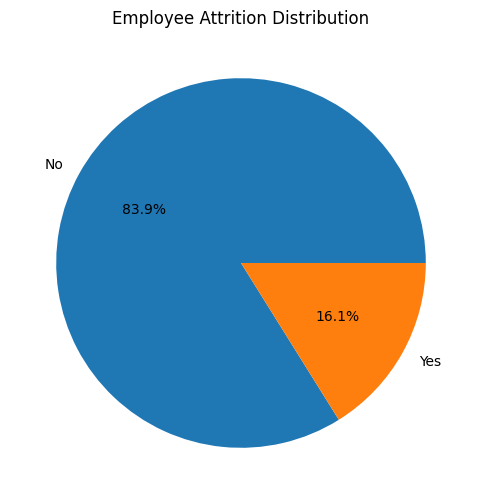

In [4]:
plt.figure(figsize=(6,6))

df['Attrition'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Employee Attrition Distribution')

plt.ylabel('')

plt.show()

In [5]:
dept_attrition = pd.crosstab(
    df['Department'],
    df['Attrition']
)

dept_attrition

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


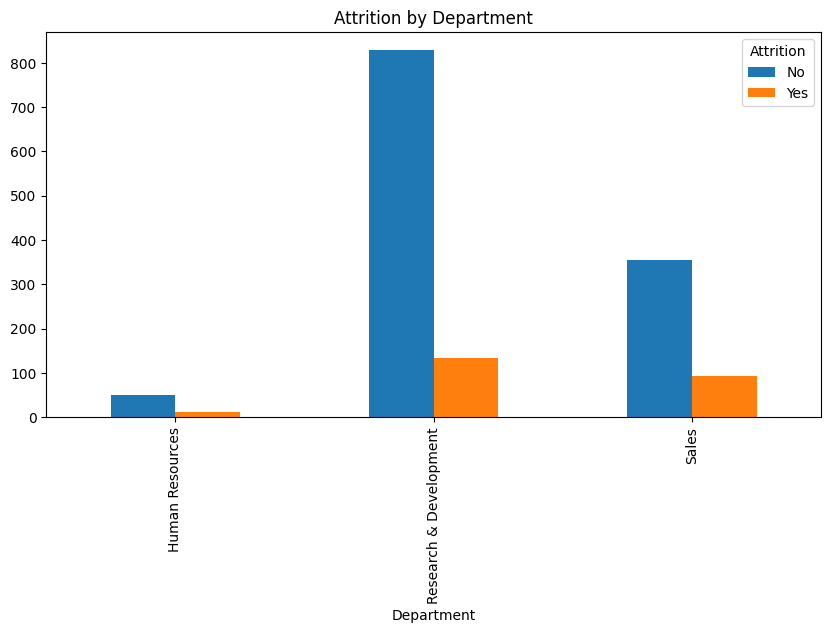

In [6]:
dept_attrition.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Attrition by Department')

plt.show()

In [7]:
job_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition']
)

job_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


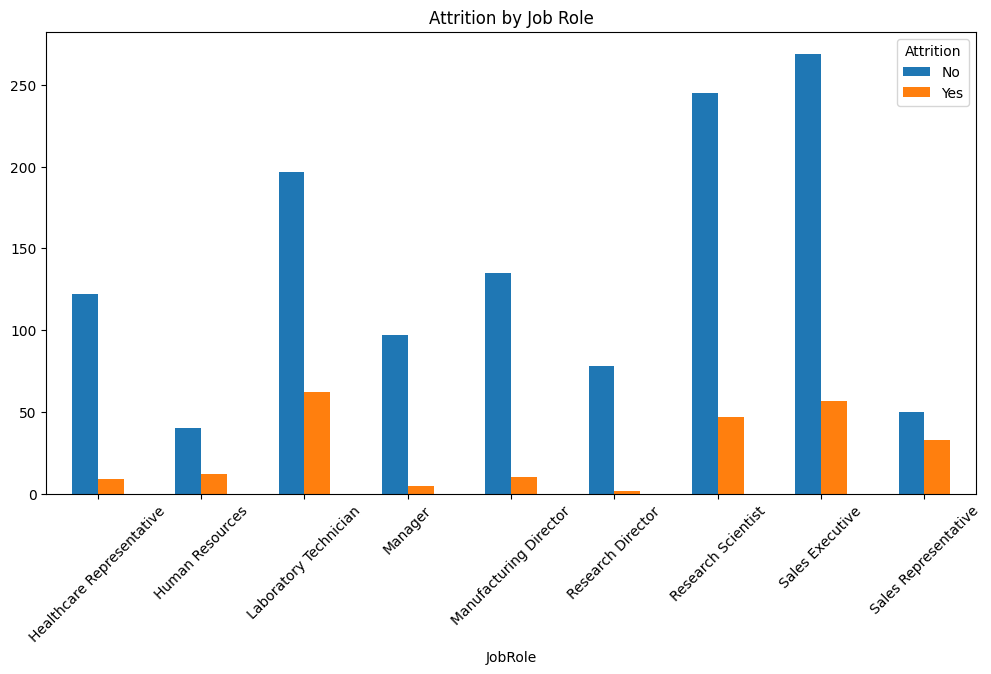

In [8]:
job_attrition.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Attrition by Job Role')

plt.xticks(rotation=45)

plt.show()

In [9]:
overtime = pd.crosstab(
    df['OverTime'],
    df['Attrition']
)

overtime

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


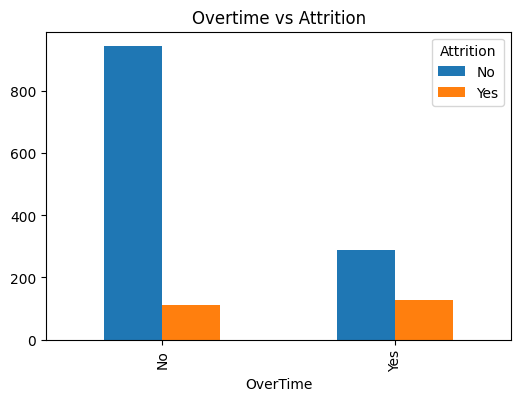

In [10]:
overtime.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Overtime vs Attrition')

plt.show()

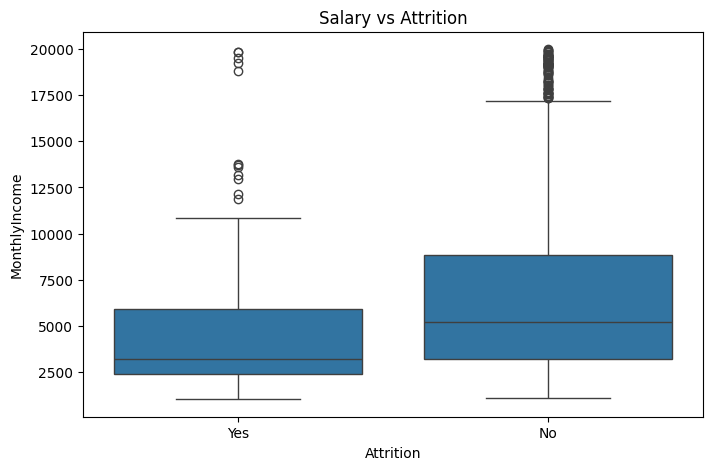

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.title('Salary vs Attrition')

plt.show()

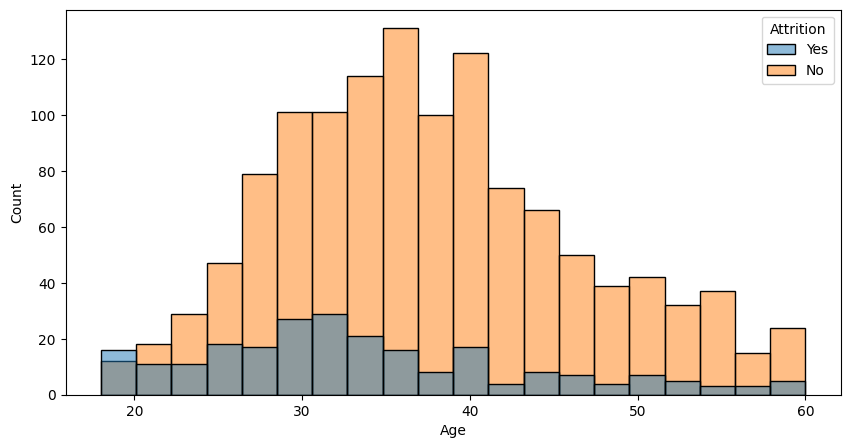

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='Age',
    hue='Attrition',
    bins=20
)

plt.show()

In [13]:
age_attrition = pd.crosstab(
    df['AgeGroup'],
    df['Attrition']
)

age_attrition

Attrition,No,Yes
AgeGroup,,
18-25,75,40
26-35,490,116
36-45,425,43
46-55,200,26
55+,39,8


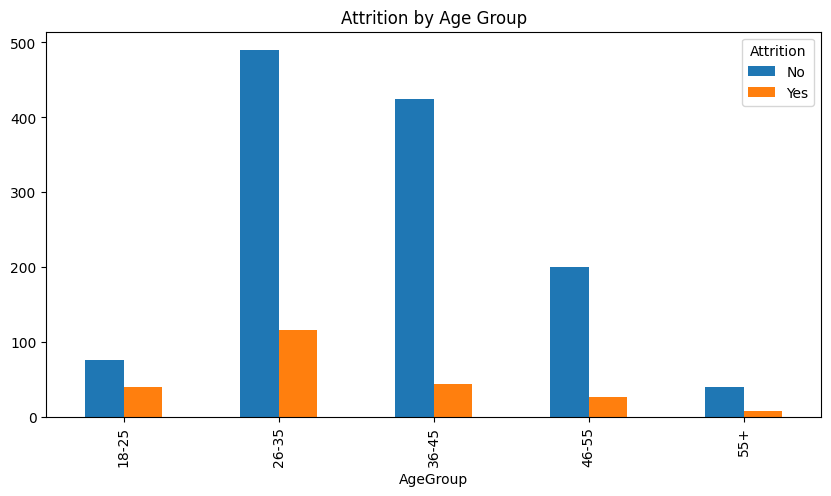

In [14]:
age_attrition.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Attrition by Age Group')

plt.show()

In [15]:
satisfaction = pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition']
)

satisfaction

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


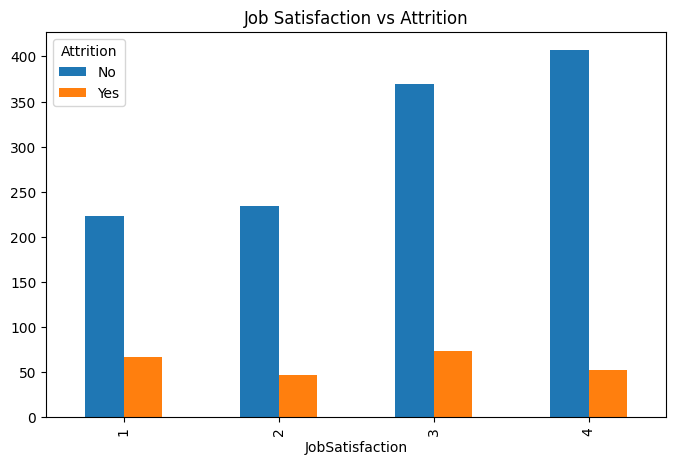

In [16]:
satisfaction.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Job Satisfaction vs Attrition')

plt.show()

In [17]:
risk = pd.crosstab(
    df['RiskCategory'],
    df['Attrition']
)

risk

Attrition,No,Yes
RiskCategory,,
Critical Risk,15,24
High Risk,130,78
Low Risk,679,48
Medium Risk,409,87


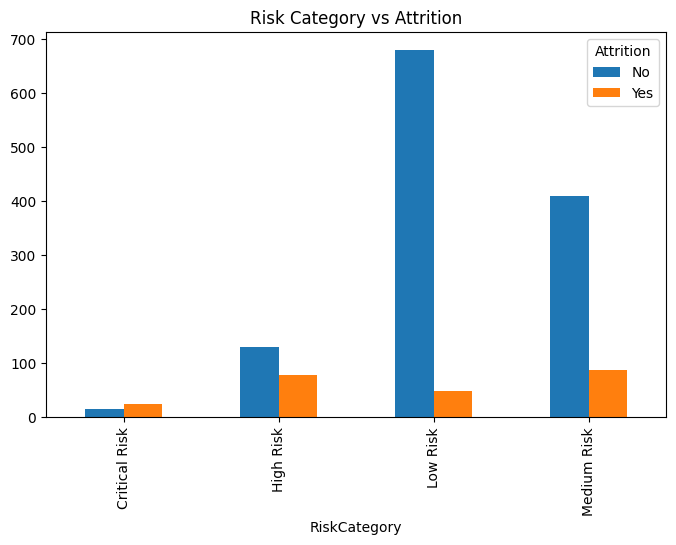

In [18]:
risk.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Risk Category vs Attrition')

plt.show()

In [19]:
numeric_df = df.select_dtypes(
    include=['int64','float64']
)

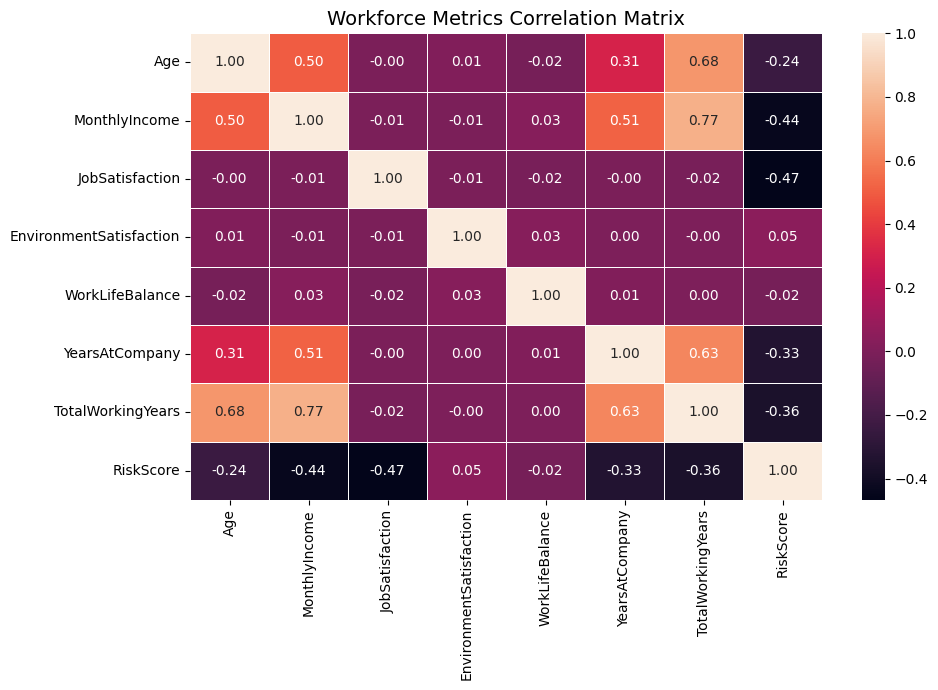

In [20]:
important_cols = [
    'Age',
    'MonthlyIncome',
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'WorkLifeBalance',
    'YearsAtCompany',
    'TotalWorkingYears',
    'RiskScore'
]

corr = df[important_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    linewidths=0.5
)

plt.title(
    'Workforce Metrics Correlation Matrix',
    fontsize=14
)

plt.tight_layout()

plt.show()

In [21]:
corr = numeric_df.corr()

corr['RiskScore'].sort_values(
    ascending=False
)

RiskScore                   1.000000
EnvironmentSatisfaction     0.047459
HourlyRate                  0.036209
RelationshipSatisfaction    0.027598
PerformanceRating           0.021945
PercentSalaryHike           0.016672
JobInvolvement              0.016565
DistanceFromHome            0.007342
EmployeeNumber              0.001140
TrainingTimesLastYear      -0.012727
MonthlyRate                -0.013387
WorkLifeBalance            -0.020750
StockOptionLevel           -0.038278
DailyRate                  -0.044257
NumCompaniesWorked         -0.055296
Education                  -0.089460
YearsSinceLastPromotion    -0.193772
EmployeeExperienceIndex    -0.221555
Age                        -0.239681
YearsWithCurrManager       -0.308031
YearsInCurrentRole         -0.329914
YearsAtCompany             -0.333680
TotalWorkingYears          -0.358699
MonthlyIncome              -0.443982
JobLevel                   -0.458125
JobSatisfaction            -0.467263
EmployeeCount                    NaN
S

In [22]:
print("EDA Completed Successfully")

EDA Completed Successfully
